# 08 - Consolidado de Matrículas por Estado (2022–2025)

Este notebook consolida dados de matrículas por estado para:
- **Educação Infantil**
- **Ensino Fundamental I** (anos iniciais)
- **Ensino Fundamental II** (anos finais)
- **Ensino Médio**
- **Ensino Superior**

**Anos disponíveis:**
- Censo Escolar: 2022, 2023, 2024, 2025
- Ensino Superior: 2022, 2023, 2024

In [2]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 1.5 MB/s eta 0:00:00a 0:00:01m


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurações de visualização
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_palette('husl')

data_dir = '../data'
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 1. Censo Escolar (2022–2024) — Formato Antigo

In [4]:
def carregar_censo_escolar_antigo(ano):
    """Carrega dados do Censo Escolar no formato antigo (arquivo único)."""
    # 2022 tem subdiretório extra 'microdados/'; 2023 e 2024 não
    if ano == 2022:
        caminho = f'{data_dir}/microdados_censo_escolar_{ano}/microdados/dados/microdados_ed_basica_{ano}.csv'
    else:
        caminho = f'{data_dir}/microdados_censo_escolar_{ano}/dados/microdados_ed_basica_{ano}.csv'
    cols_desejadas = ['SG_UF', 'QT_MAT_INF', 'QT_MAT_FUND_AI', 'QT_MAT_FUND_AF', 'QT_MAT_MED']
    
    df = pd.read_csv(caminho, sep=';', encoding='latin-1', low_memory=False)
    
    # Verificar se QT_MAT_INF existe; senão, tentar combinar creche + pré-escola
    if 'QT_MAT_INF' not in df.columns:
        df['QT_MAT_INF'] = df.get('QT_MAT_CRE', 0).fillna(0) + df.get('QT_MAT_PRE', 0).fillna(0)
    
    # Garantir que todas as colunas existam
    for col in cols_desejadas:
        if col not in df.columns:
            df[col] = 0
    
    df_estado = df.groupby('SG_UF')[cols_desejadas[1:]].sum().reset_index()
    df_estado['ANO'] = ano
    return df_estado

# Carregar 2022, 2023, 2024
dfs_escolar_antigo = []
for ano in [2022, 2023, 2024]:
    df_ano = carregar_censo_escolar_antigo(ano)
    dfs_escolar_antigo.append(df_ano)
    print(f'{ano}: {len(df_ano)} estados carregados')

df_escolar_antigo = pd.concat(dfs_escolar_antigo, ignore_index=True)
print(f'\nTotal consolidado (2022–2024): {len(df_escolar_antigo)} registros')
df_escolar_antigo.head()

2022: 27 estados carregados
2023: 27 estados carregados
2024: 27 estados carregados

Total consolidado (2022–2024): 81 registros


,SG_UF,QT_MAT_INF,QT_MAT_FUND_AI,QT_MAT_FUND_AF,QT_MAT_MED,ANO
0,AC,37760.0,84278.0,65367.0,41636.0,2022
1,AL,138989.0,244875.0,208417.0,127502.0,2022
2,AM,162070.0,393340.0,303557.0,199896.0,2022
3,AP,26557.0,75504.0,57000.0,32873.0,2022
4,BA,566774.0,1025289.0,885200.0,569637.0,2022


## 2. Censo Escolar 2025 — Formato Novo (Tabela Escola + Tabela Matrícula)

In [5]:
# Carregar Tabela Escola e Tabela Matrícula de 2025
escola_2025 = pd.read_csv(
    f'{data_dir}/microdados_censo_escolar_2025_/microdados_censo_escolar_2025/dados/Tabela_Escola_2025.csv',
    sep=';', encoding='latin-1', low_memory=False
)
matricula_2025 = pd.read_csv(
    f'{data_dir}/microdados_censo_escolar_2025_/microdados_censo_escolar_2025/dados/Tabela_Matricula_2025.csv',
    sep=';', encoding='latin-1', low_memory=False
)

print(f'Escola 2025: {escola_2025.shape}')
print(f'Matrícula 2025: {matricula_2025.shape}')

# Merge para trazer SG_UF da tabela escola
df_2025 = matricula_2025.merge(escola_2025[['CO_ENTIDADE', 'SG_UF']], on='CO_ENTIDADE', how='left')

cols_mat = ['QT_MAT_INF', 'QT_MAT_FUND_AI', 'QT_MAT_FUND_AF', 'QT_MAT_MED']
for col in cols_mat:
    if col not in df_2025.columns:
        df_2025[col] = 0

df_escolar_2025 = df_2025.groupby('SG_UF')[cols_mat].sum().reset_index()
df_escolar_2025['ANO'] = 2025

print(f'2025: {len(df_escolar_2025)} estados carregados')
df_escolar_2025.head()

Escola 2025: (214192, 302)
Matrícula 2025: (178766, 237)
2025: 27 estados carregados


,SG_UF,QT_MAT_INF,QT_MAT_FUND_AI,QT_MAT_FUND_AF,QT_MAT_MED,ANO
0,AC,39559,81006,61486,37266,2025
1,AL,157135,239684,190896,122787,2025
2,AM,178941,384463,296226,191839,2025
3,AP,29581,75374,53405,33626,2025
4,BA,582760,996376,794612,479086,2025


## 3. Ensino Superior (2022–2024)

In [6]:
def carregar_ensino_superior(ano):
    """Carrega dados do Censo da Educação Superior e agrupa matrículas por estado."""
    if ano == 2022:
        base_dir = f'{data_dir}/microdados_censo_da_educacao_superior_2022/microdados_educaç╞o_superior_2022/dados'
    else:
        base_dir = f'{data_dir}/microdados_censo_da_educacao_superior_{ano}/dados'
    
    ies = pd.read_csv(f'{base_dir}/MICRODADOS_ED_SUP_IES_{ano}.CSV', sep=';', encoding='latin-1')
    cursos = pd.read_csv(f'{base_dir}/MICRODADOS_CADASTRO_CURSOS_{ano}.CSV', sep=';', encoding='latin-1', low_memory=False)
    
    merged = cursos.merge(ies[['CO_IES', 'SG_UF_IES']], on='CO_IES', how='left')
    df_estado = merged.groupby('SG_UF_IES')['QT_MAT'].sum().reset_index()
    df_estado.columns = ['SG_UF', 'QT_MAT_SUP']
    df_estado['ANO'] = ano
    return df_estado

dfs_superior = []
for ano in [2022, 2023, 2024]:
    df_ano = carregar_ensino_superior(ano)
    dfs_superior.append(df_ano)
    print(f'Superior {ano}: {len(df_ano)} estados carregados')

df_superior = pd.concat(dfs_superior, ignore_index=True)
print(f'\nTotal consolidado (2022–2024): {len(df_superior)} registros')
df_superior.head()

Superior 2022: 27 estados carregados
Superior 2023: 27 estados carregados
Superior 2024: 27 estados carregados

Total consolidado (2022–2024): 81 registros


,SG_UF,QT_MAT_SUP,ANO
0,AC,20101,2022
1,AL,71788,2022
2,AM,114839,2022
3,AP,27727,2022
4,BA,292159,2022


## 4. Consolidação Geral

In [7]:
# Unificar Censo Escolar (2022–2025)
df_escolar = pd.concat([df_escolar_antigo, df_escolar_2025], ignore_index=True)

# Adicionar Ensino Superior (2022–2024) — 2025 não disponível
df_consolidado = df_escolar.merge(df_superior, on=['SG_UF', 'ANO'], how='outer')

# Ordenar
df_consolidado = df_consolidado.sort_values(['SG_UF', 'ANO']).reset_index(drop=True)

# Renomear colunas para melhor leitura
df_consolidado.rename(columns={
    'QT_MAT_INF': 'Educacao_Infantil',
    'QT_MAT_FUND_AI': 'Fundamental_I',
    'QT_MAT_FUND_AF': 'Fundamental_II',
    'QT_MAT_MED': 'Ensino_Medio',
    'QT_MAT_SUP': 'Ensino_Superior'
}, inplace=True)

# Garantir tipos numéricos
for col in ['Educacao_Infantil', 'Fundamental_I', 'Fundamental_II', 'Ensino_Medio', 'Ensino_Superior']:
    df_consolidado[col] = pd.to_numeric(df_consolidado[col], errors='coerce').fillna(0).astype(int)

print(f'Dimensão do DataFrame consolidado: {df_consolidado.shape}')
print('\nPrimeiros registros:')
display(df_consolidado.head(10))

print('\nResumo por ano:')
print(df_consolidado.groupby('ANO')[['Educacao_Infantil', 'Fundamental_I', 'Fundamental_II', 'Ensino_Medio', 'Ensino_Superior']].sum())

Dimensão do DataFrame consolidado: (108, 7)

Primeiros registros:


,SG_UF,Educacao_Infantil,Fundamental_I,Fundamental_II,Ensino_Medio,ANO,Ensino_Superior
0,AC,37760,84278,65367,41636,2022,20101
1,AC,40234,83508,63842,40216,2023,19233
2,AC,39167,81085,61416,40079,2024,18648
3,AC,39559,81006,61486,37266,2025,0
4,AL,138989,244875,208417,127502,2022,71788
5,AL,151297,238611,200403,120878,2023,73751
6,AL,158189,239689,199786,127231,2024,74445
7,AL,157135,239684,190896,122787,2025,0
8,AM,162070,393340,303557,199896,2022,114839
9,AM,174229,389364,303259,189771,2023,132211



Resumo por ano:
      Educacao_Infantil  Fundamental_I  Fundamental_II  Ensino_Medio  \
ANO                                                                    
2022            9028764       14553030        11899198       7866695   
2023            9461155       14426650        11681558       7676743   
2024            9491894       14498233        11504123       7790396   
2025            9286182       14514244        11292523       7370879   

      Ensino_Superior  
ANO                    
2022          9444116  
2023          9977217  
2024         10227266  
2025                0  


## 5. Tabela Pivot Completa por Estado

In [8]:
# Criar tabela pivot com multi-colunas para facilitar leitura
niveis = ['Educacao_Infantil', 'Fundamental_I', 'Fundamental_II', 'Ensino_Medio', 'Ensino_Superior']

pivot_tables = {}
for nivel in niveis:
    pivot = df_consolidado.pivot(index='SG_UF', columns='ANO', values=nivel).fillna(0).astype(int)
    pivot_tables[nivel] = pivot
    print(f'\n=== {nivel.upper().replace("_", " ")} ===')
    display(pivot)

# Total de matrículas por estado e ano (soma de todos os níveis disponíveis no ano)
df_total = df_consolidado.groupby(['SG_UF', 'ANO'])[niveis].sum().reset_index()
df_total['Total_Geral'] = df_total[niveis].sum(axis=1)
pivot_total = df_total.pivot(index='SG_UF', columns='ANO', values='Total_Geral').fillna(0).astype(int)
print('\n=== TOTAL GERAL (todos os níveis) ===')
display(pivot_total)


=== EDUCACAO INFANTIL ===


ANO,2022,2023,2024,2025
SG_UF,,,,
AC,37760,40234,39167,39559
AL,138989,151297,158189,157135
AM,162070,174229,177055,178941
AP,26557,28990,29916,29581
BA,566774,594736,597667,582760
CE,430201,445510,442621,431562
DF,105465,108603,110408,107953
ES,177928,184113,184322,181482
GO,257217,277424,285341,283530



=== FUNDAMENTAL I ===


ANO,2022,2023,2024,2025
SG_UF,,,,
AC,84278,83508,81085,81006
AL,244875,238611,239689,239684
AM,393340,389364,388838,384463
AP,75504,76034,76270,75374
BA,1025289,1010398,1011704,996376
CE,624614,622947,632763,640513
DF,202627,200631,203015,200751
ES,282218,280576,284533,286875
GO,478804,485416,495551,500276



=== FUNDAMENTAL II ===


...

ANO,2022,2023,2024,2025
SG_UF,,,,
AC,41636,40216,40079,37266
AL,127502,120878,127231,122787
AM,199896,189771,192683,191839
AP,32873,32435,33346,33626
BA,569637,517073,510586,479086
CE,359427,358735,364898,356773
DF,114414,111437,104486,105044
ES,127054,126068,127820,127580
GO,249164,224130,240835,238959



=== ENSINO SUPERIOR ===


ANO,2022,2023,2024,2025
SG_UF,,,,
AC,20101,19233,18648,0
AL,71788,73751,74445,0
AM,114839,132211,129203,0
AP,27727,24627,25831,0
BA,292159,281101,286156,0
CE,233944,248858,267091,0
DF,208196,214852,221603,0
ES,116418,116979,120679,0
GO,168151,179294,184999,0



=== TOTAL GERAL (todos os níveis) ===


ANO,2022,2023,2024,2025
SG_UF,,,,
AC,249142,247033,240395,219317
AL,791571,784940,799340,710502
AM,1173702,1188834,1188066,1051469
AP,219661,218000,219675,191986
BA,3339059,3258484,3236759,2852834
CE,2176798,2187739,2205035,1917959
DF,793154,796330,797438,567370
ES,923319,925517,933053,811788
GO,1537344,1549070,1589309,1398211


## 6. Visualização — Evolução por Nível de Ensino (Brasil)

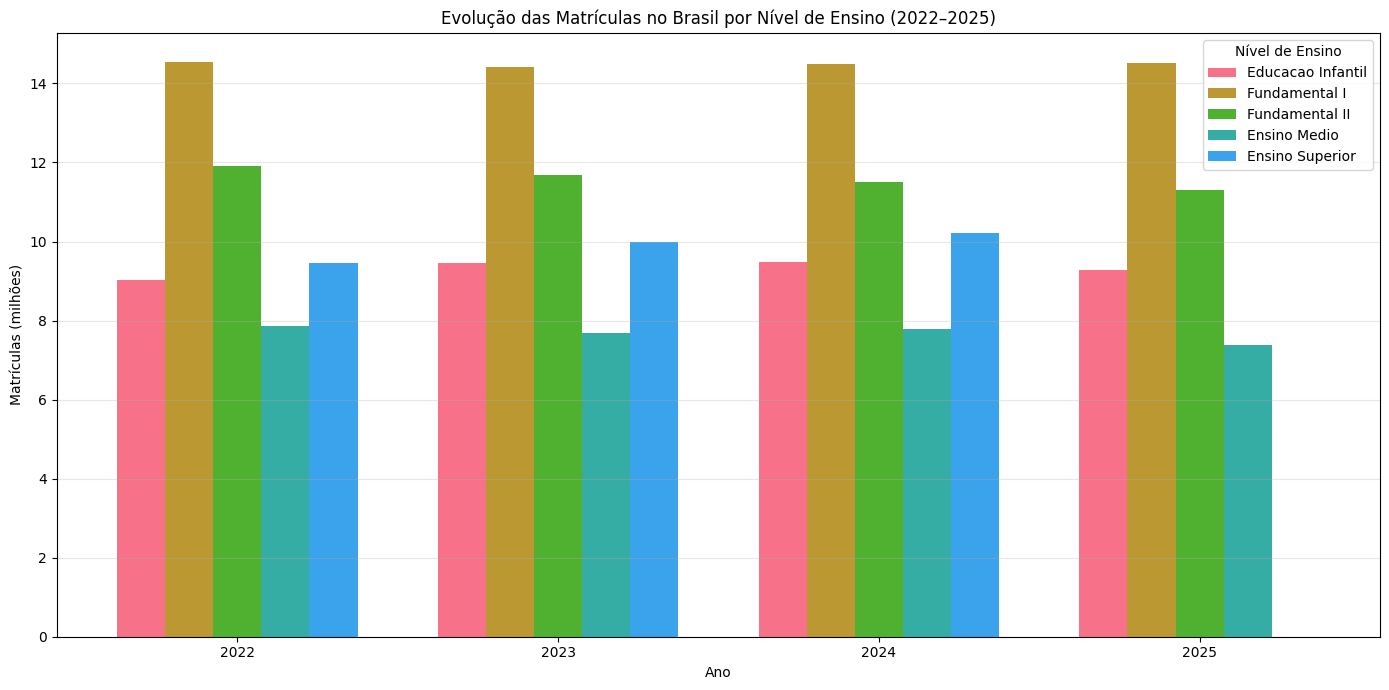

,ANO,Educacao_Infantil,Fundamental_I,Fundamental_II,Ensino_Medio,Ensino_Superior
0,2022,"9,028,764","14,553,030","11,899,198","7,866,695","9,444,116"
1,2023,"9,461,155","14,426,650","11,681,558","7,676,743","9,977,217"
2,2024,"9,491,894","14,498,233","11,504,123","7,790,396","10,227,266"
3,2025,"9,286,182","14,514,244","11,292,523","7,370,879",0


In [9]:
# Somar por ano para todo o Brasil
df_brasil = df_consolidado.groupby('ANO')[niveis].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_brasil))
width = 0.15

for i, nivel in enumerate(niveis):
    offset = (i - 2) * width
    bars = ax.bar(x + offset, df_brasil[nivel] / 1_000_000, width, label=nivel.replace('_', ' '))

ax.set_xlabel('Ano')
ax.set_ylabel('Matrículas (milhões)')
ax.set_title('Evolução das Matrículas no Brasil por Nível de Ensino (2022–2025)')
ax.set_xticks(x)
ax.set_xticklabels(df_brasil['ANO'].astype(str))
ax.legend(title='Nível de Ensino')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Exibir tabela numérica
df_brasil_fmt = df_brasil.copy()
for col in niveis:
    df_brasil_fmt[col] = df_brasil_fmt[col].apply(lambda x: f'{x:,.0f}')
display(df_brasil_fmt)

## 7. Visualização — Heatmap por Estado e Ano (Ensino Médio)

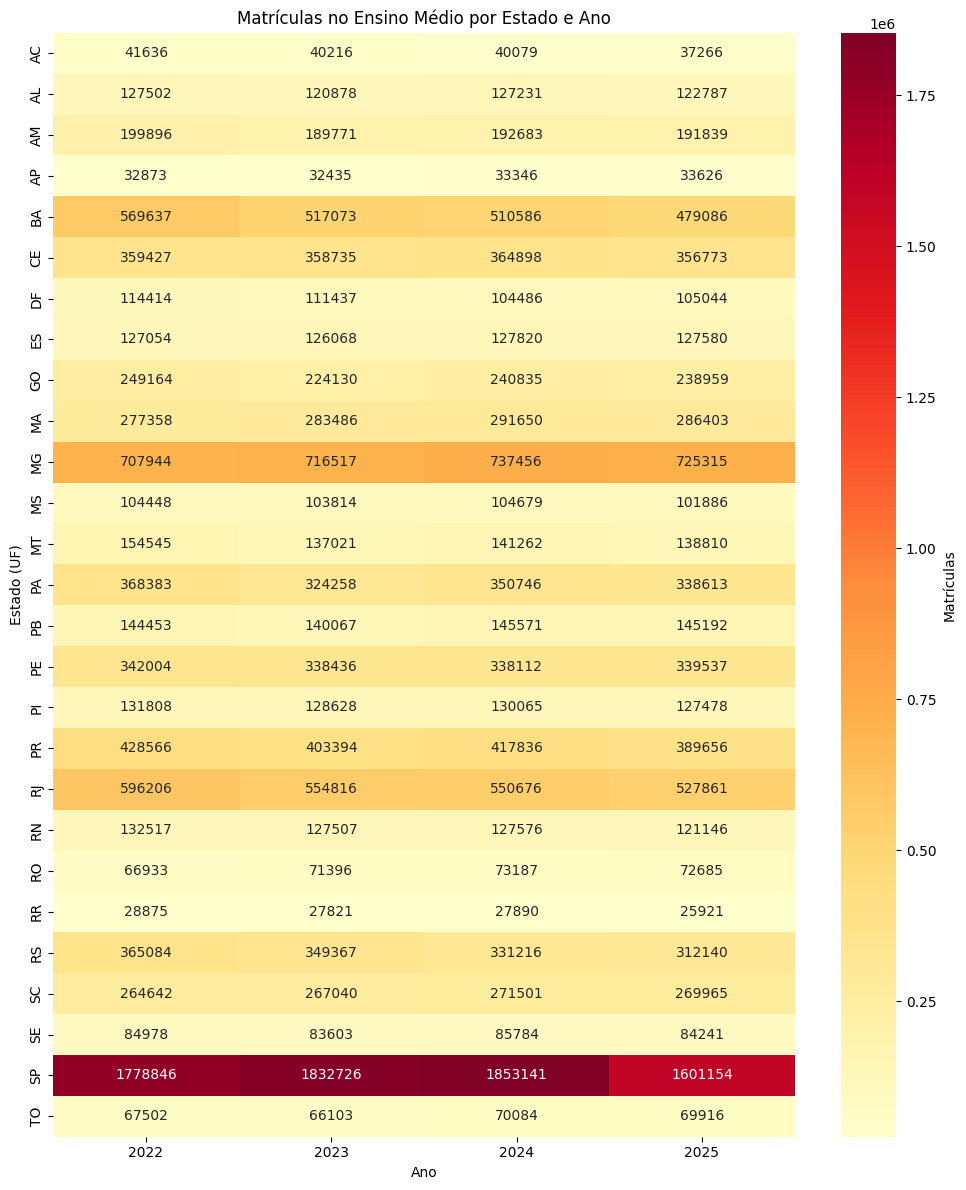

In [10]:
# Heatmap para Ensino Médio
pivot_medio = df_consolidado.pivot(index='SG_UF', columns='ANO', values='Ensino_Medio').fillna(0).astype(int)

plt.figure(figsize=(10, 12))
sns.heatmap(pivot_medio, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Matrículas'})
plt.title('Matrículas no Ensino Médio por Estado e Ano')
plt.xlabel('Ano')
plt.ylabel('Estado (UF)')
plt.tight_layout()
plt.show()

## 8. Visualização — Comparativo 2024 vs 2025 (Censo Escolar)

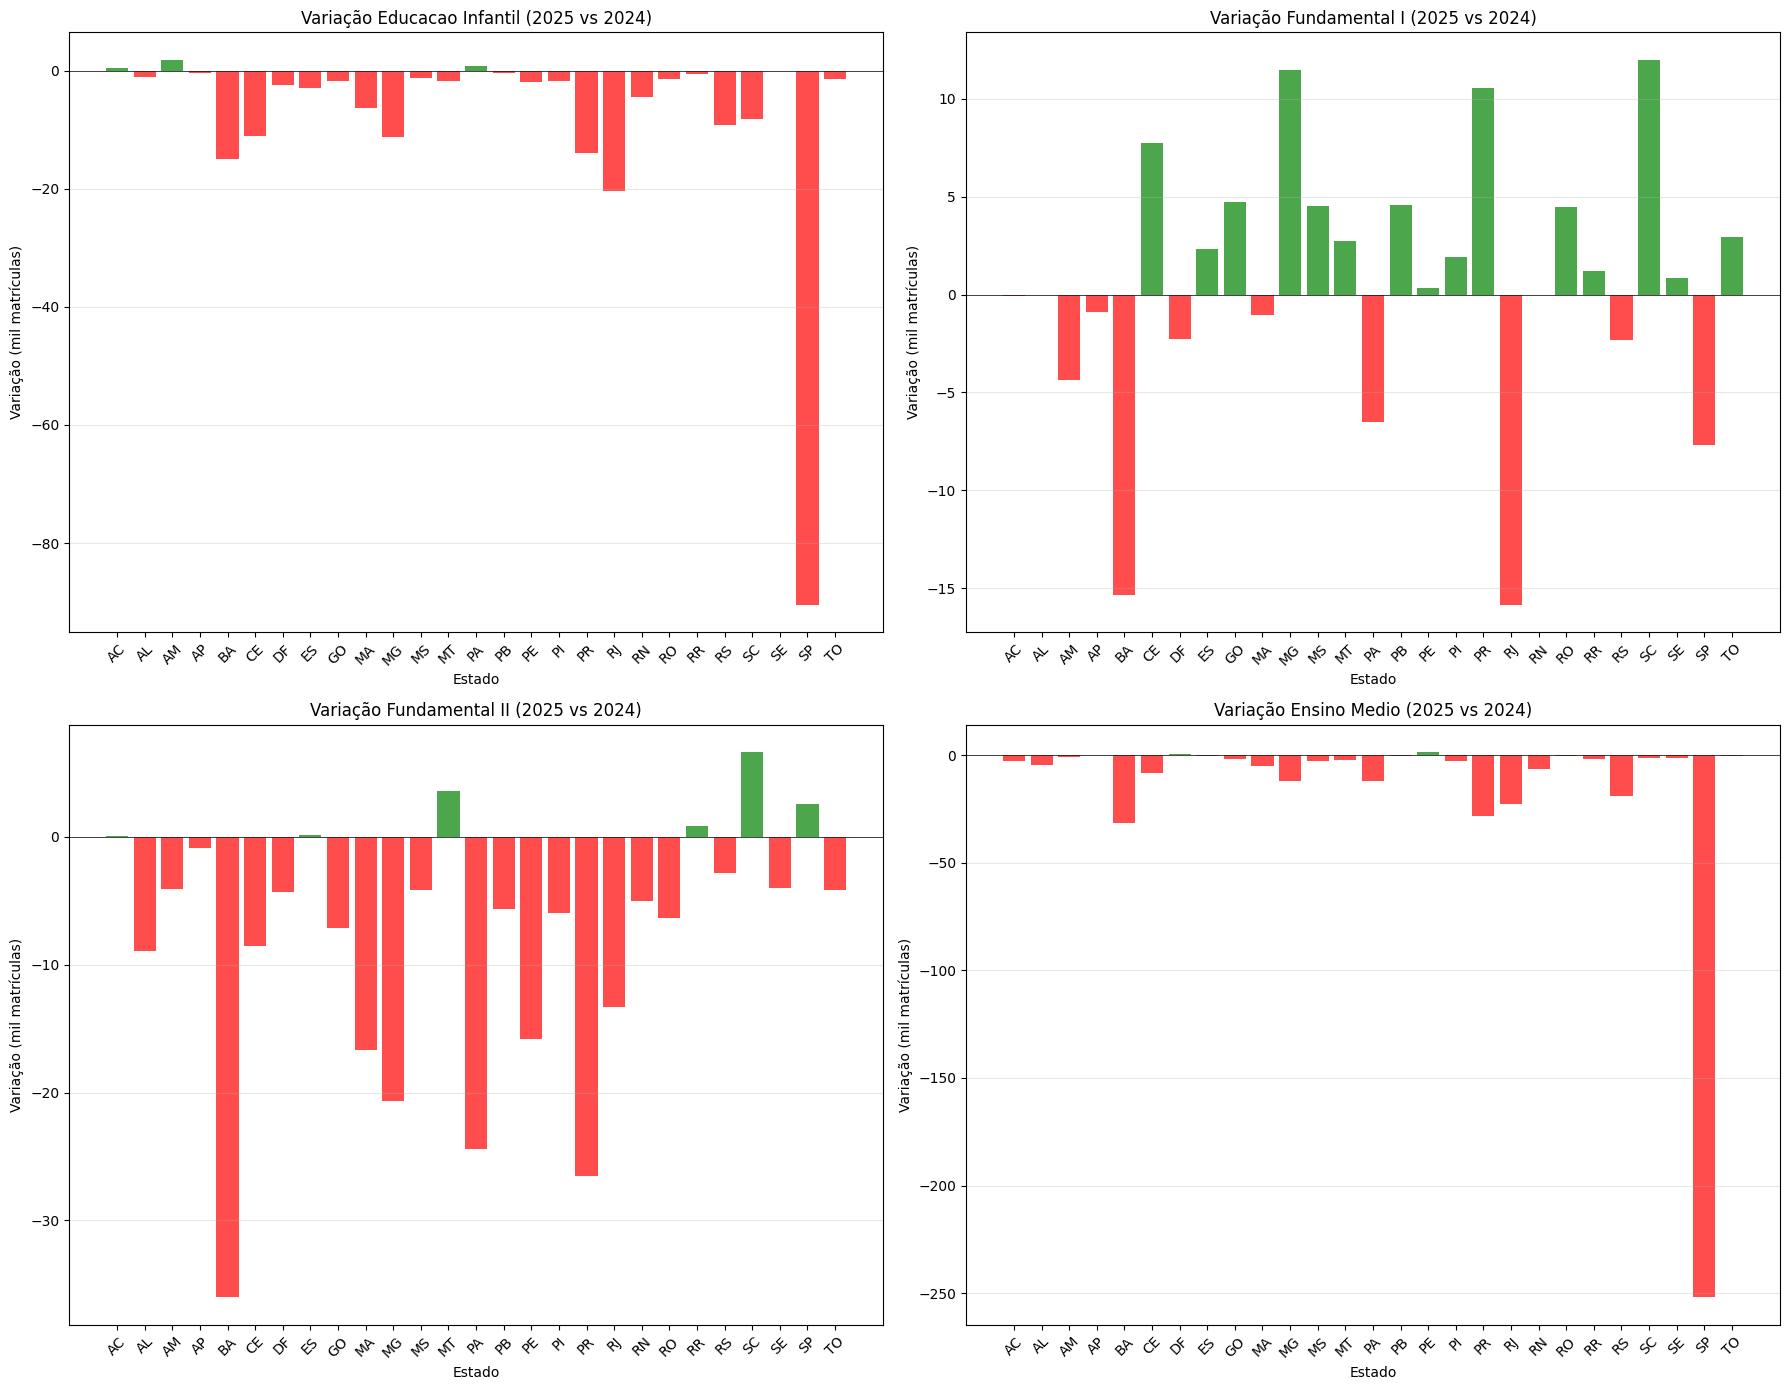

In [11]:
# Comparar 2024 e 2025 apenas para níveis disponíveis em ambos
df_comp = df_consolidado[df_consolidado['ANO'].isin([2024, 2025])].copy()
niveis_escolar = ['Educacao_Infantil', 'Fundamental_I', 'Fundamental_II', 'Ensino_Medio']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, nivel in zip(axes, niveis_escolar):
    pivot_nivel = df_comp.pivot(index='SG_UF', columns='ANO', values=nivel).fillna(0).astype(int)
    if 2024 in pivot_nivel.columns and 2025 in pivot_nivel.columns:
        pivot_nivel['Variacao'] = pivot_nivel[2025] - pivot_nivel[2024]
        cores = pivot_nivel['Variacao'].apply(lambda x: 'green' if x > 0 else 'red')
        ax.bar(pivot_nivel.index, pivot_nivel['Variacao'] / 1000, color=cores, alpha=0.7)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_title(f'Variação {nivel.replace("_", " ")} (2025 vs 2024)')
        ax.set_xlabel('Estado')
        ax.set_ylabel('Variação (mil matrículas)')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Visualização — Ensino Superior por Ano

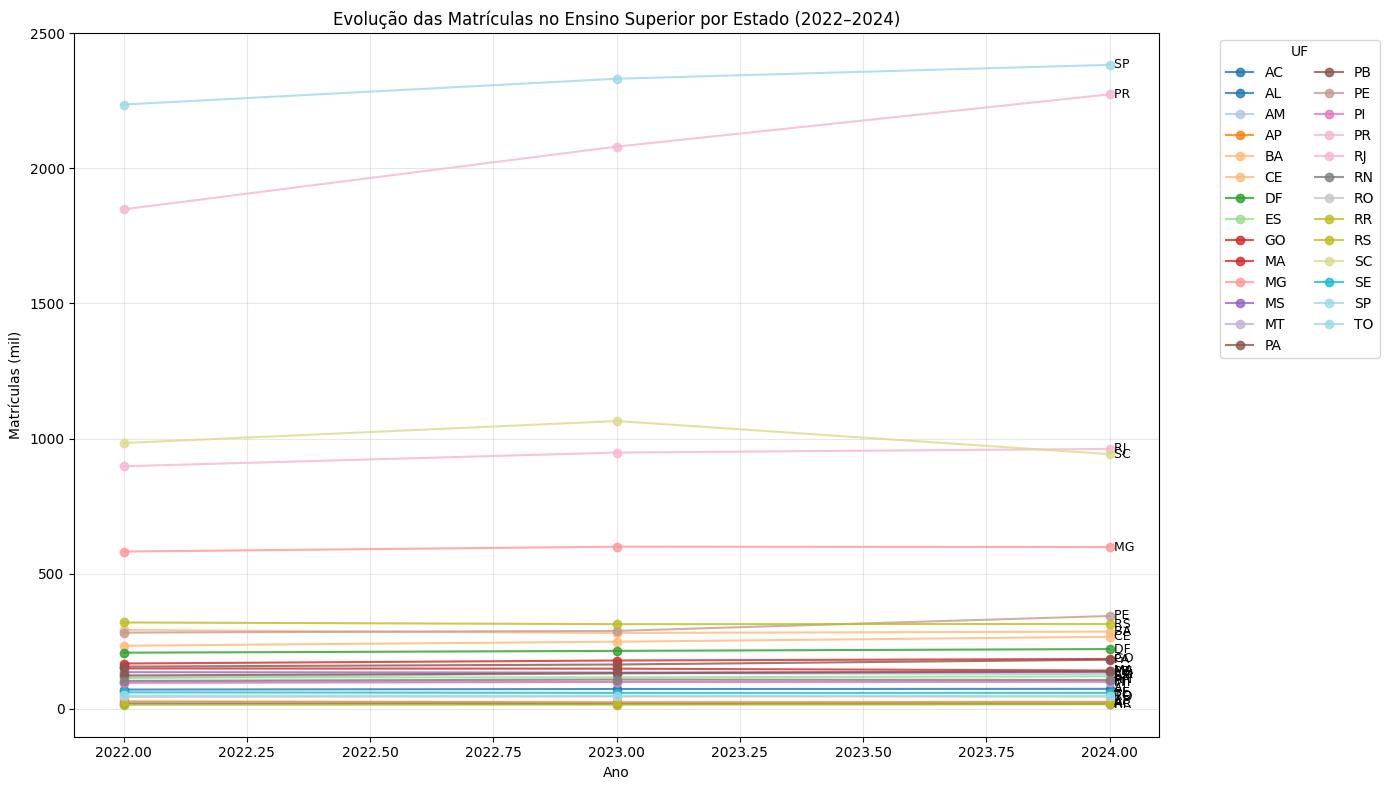

Matrículas no Ensino Superior por Estado e Ano:


ANO,2022,2023,2024
SG_UF,,,
AC,20101,19233,18648
AL,71788,73751,74445
AM,114839,132211,129203
AP,27727,24627,25831
BA,292159,281101,286156
CE,233944,248858,267091
DF,208196,214852,221603
ES,116418,116979,120679
GO,168151,179294,184999


In [13]:
# Gráfico de linhas para Ensino Superior por estado
# Exibe a sigla (UF) ao final de cada linha para facilitar identificação

df_sup = df_consolidado[df_consolidado['Ensino_Superior'] > 0].copy()
pivot_sup = df_sup.pivot(index='SG_UF', columns='ANO', values='Ensino_Superior').fillna(0).astype(int)

plt.figure(figsize=(14, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(pivot_sup.index)))

for idx, uf in enumerate(pivot_sup.index):
    anos = pivot_sup.columns
    vals = pivot_sup.loc[uf] / 1000
    plt.plot(anos, vals, marker='o', label=uf, alpha=0.8, color=colors[idx])
    
    # Adicionar sigla do estado ao final da linha
    ultimo_ano = anos[-1]
    ultimo_val = vals.iloc[-1]
    plt.text(ultimo_ano, ultimo_val, f' {uf}', fontsize=9, va='center')

plt.title('Evolução das Matrículas no Ensino Superior por Estado (2022–2024)')
plt.xlabel('Ano')
plt.ylabel('Matrículas (mil)')
plt.legend(title='UF', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabela pivot do Ensino Superior
print('Matrículas no Ensino Superior por Estado e Ano:')
display(pivot_sup)

## 10. Exportar CSV Consolidado

In [14]:
caminho_saida = f'{data_dir}/df_consolidado_matriculas_2022_2025.csv'
df_consolidado.to_csv(caminho_saida, index=False, encoding='utf-8')
print(f'Dados consolidados salvos em: {caminho_saida}')
print(f'Total de registros: {len(df_consolidado)}')
print(f'Estados: {sorted(df_consolidado["SG_UF"].dropna().unique())}')
print(f'Anos: {sorted(df_consolidado["ANO"].dropna().unique())}')

Dados consolidados salvos em: ../data/df_consolidado_matriculas_2022_2025.csv
Total de registros: 108
Estados: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']
Anos: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
